### PMSM 2D thermal study with convection
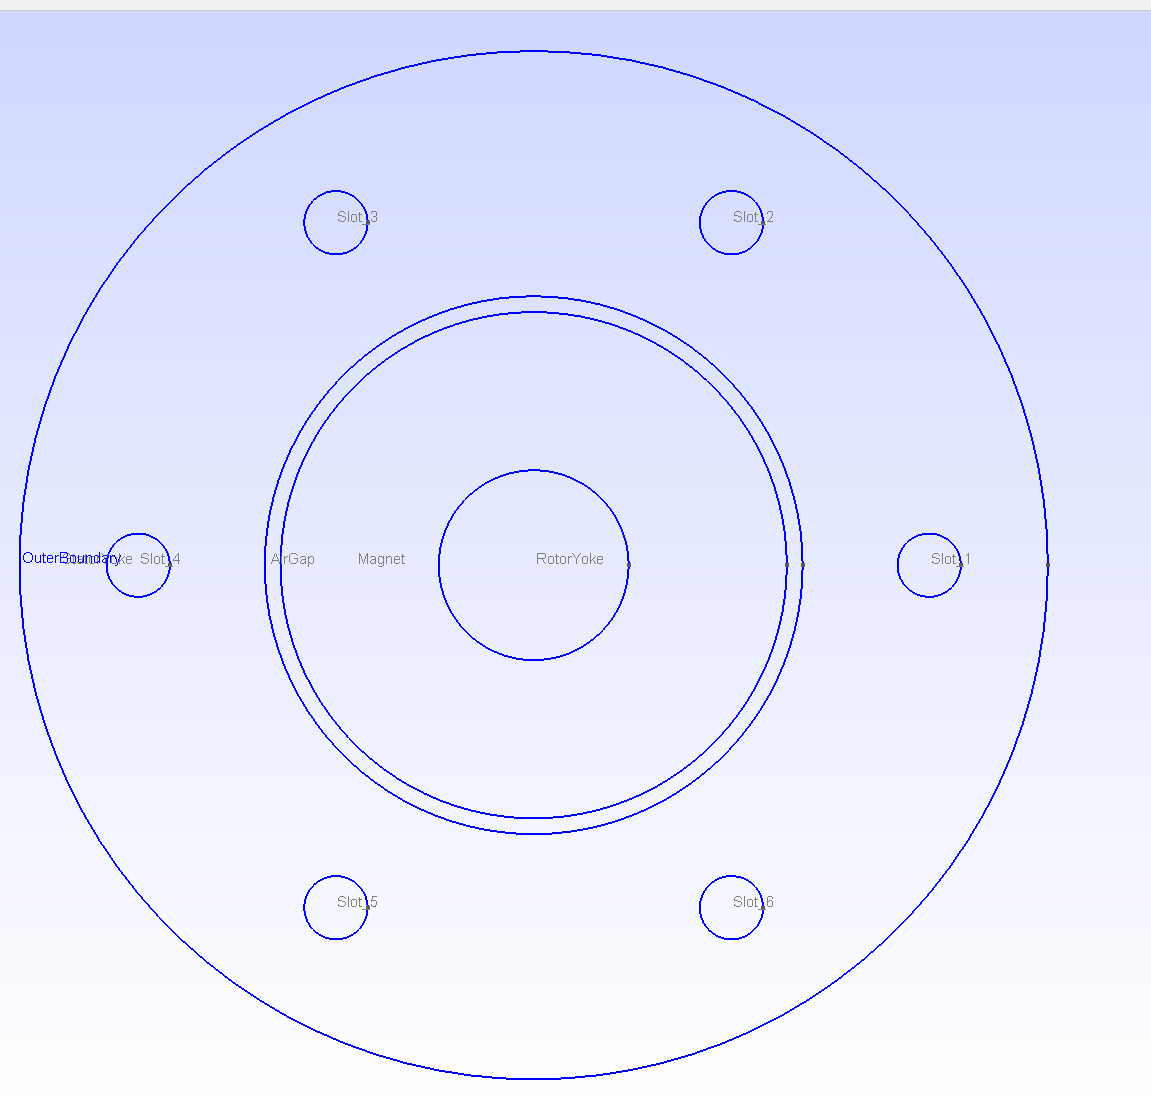

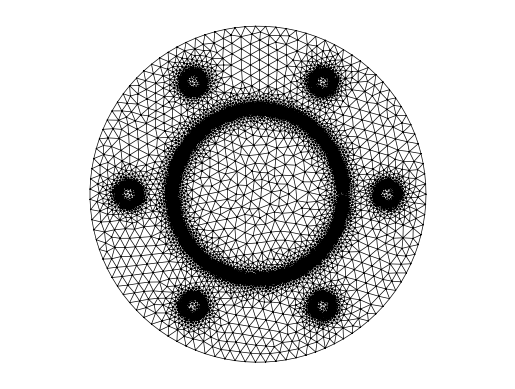

In [1]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

m = meshio.read("mesh/mesh_pmsm_2d.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()

In [4]:
from skfem import Basis, ElementTriP2

# Second order tringular elements.
e = ElementTriP2()
basis = Basis(mesh, e, intorder=4)

basis_plate = basis.with_elements(mesh.subdomains["ThermalDomain"])

# Dirichelt Boundaries
D_left = basis.get_dofs(
    facets=mesh.boundaries["Temperature_Left"]
)

D_right = basis.get_dofs(
    facets=mesh.boundaries["Temperature_Right"]
)


# Test plate area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
plate_area = area.assemble(basis_plate)
print("In units of m: ", plate_area)


In units of m:  0.500000000000001


Weak form for this problem is:

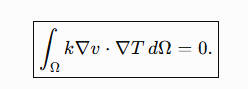

and Dirichelt BCs for left and right boundary. Top and Bottom bundary are insulated. This is essentially Neumann BC of zero, which is naturally satisfied.

In [33]:
# w.mu little coonfusing but it just wraps the permeability to some variable w

@BilinearForm
def laplace(A, v, w):
    return w.k*dot(grad(A), grad(v))


# thermal conductivity  ,  could also be 1/k thermal resitivity. Same than in magnetic problems 1/mu.
k_iron_plate = 80 # W/(m*K) 
T_left = 100.0 # degrees
T_right = 20.0 # degrees

K = laplace.assemble(basis_plate, k=k_iron_plate)
f = np.zeros(basis_plate.N)

# Boundary conditions
left_dofs = D_left.all()
right_dofs = D_right.all()

x = np.zeros(basis_plate.N)
x[left_dofs] = T_left 
x[right_dofs] = T_right


D = np.concatenate([
    left_dofs,
    right_dofs
])

K, f = enforce(K, f, D=D, x=x)

T = solve(K, f)


Visualize

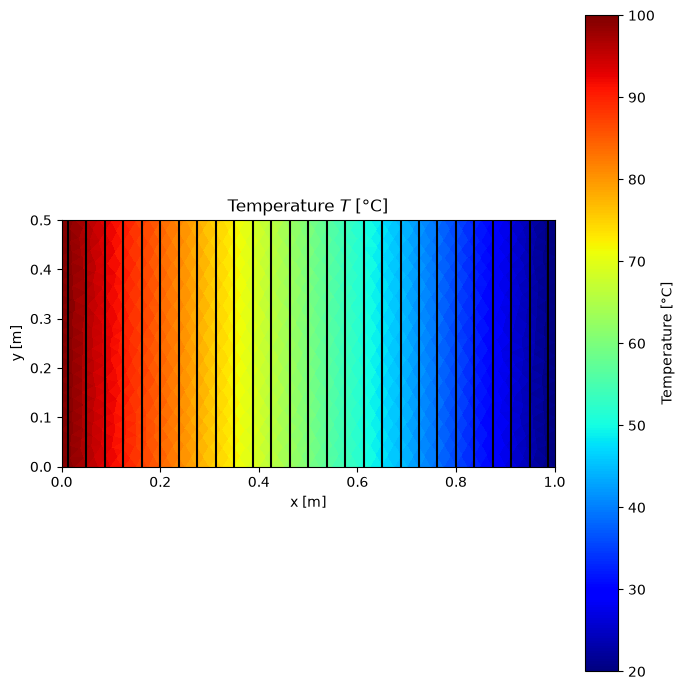

In [44]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

fig, ax = plt.subplots(figsize=(7, 7))

# Temperature field + colorbar
plot(
    basis_plate,
    T,
    shading="gouraud",
    colorbar=True,
    ax=ax,
)

# Temperature contour lines
plot(
    basis_plate,
    T,
    ax=ax,
    levels=30,
    color="black",
    linewidths=0.4,
)

# Axis formatting
ax.set_aspect("equal")
ax.set_title(r"Temperature $T$ [°C]")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

# The colorbar created by scikit-fem is the second axes
# in the figure: [main plot, colorbar]
cbar = fig.axes[-1]
cbar.set_ylabel("Temperature [°C]")

plt.tight_layout()
plt.show()

Lets solve the heat **q**. Should be form hot -> cold 

Mean |q| = 6400.000000 W/m²
Std  |q| = 1.365945e-10 W/m²


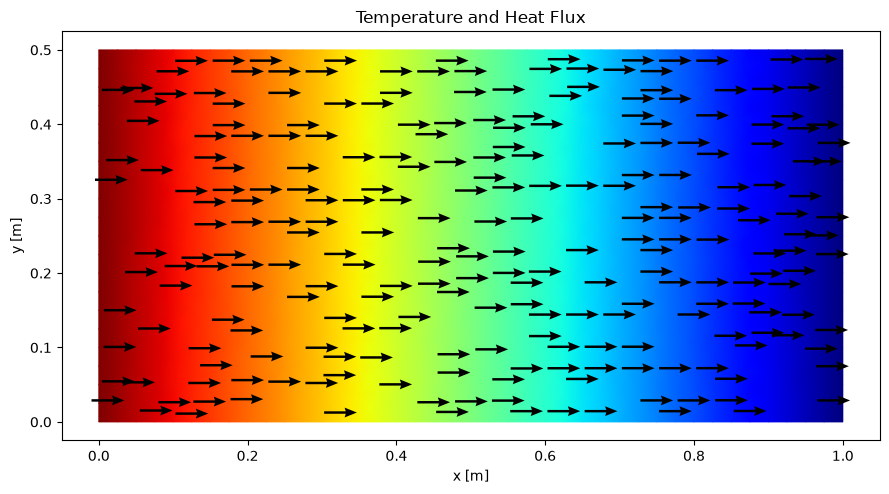

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

# ------------------------------------------------------------
# Heat flux
# ------------------------------------------------------------

uh = basis.interpolate(T)

dT_dx = uh.grad[0]
dT_dy = uh.grad[1]

# Heat flux vector q = -k * grad(T)
qx = -k_iron_plate * dT_dx
qy = -k_iron_plate * dT_dy

# Average quadrature points -> one vector per element
qx_elem = qx.mean(axis=1)
qy_elem = qy.mean(axis=1)

q_mag = np.sqrt(qx_elem**2 + qy_elem**2)


# ------------------------------------------------------------
# Element centers
# ------------------------------------------------------------

x = mesh.p[0, mesh.t]
y = mesh.p[1, mesh.t]

centers_x = x.mean(axis=0)
centers_y = y.mean(axis=0)


# ------------------------------------------------------------
# Plot temperature
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

plot(
    basis,
    T,
    shading="gouraud",
    ax=ax
)

# ------------------------------------------------------------
# Normalize heat-flux vectors
# ------------------------------------------------------------

qx_norm = qx_elem / (q_mag + 1e-20)
qy_norm = qy_elem / (q_mag + 1e-20)


# ------------------------------------------------------------
# Plot fewer arrows
# ------------------------------------------------------------

step = 2

ax.quiver(
    centers_x[::step],
    centers_y[::step],
    qx_norm[::step],
    qy_norm[::step],
    color="black",
    pivot="mid",
    scale=25,
    width=0.003,
    headwidth=4,
    headlength=5
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Temperature and Heat Flux")

plt.tight_layout()
# plt.show()

print(f"Mean |q| = {np.mean(q_mag):.6f} W/m²")
print(f"Std  |q| = {np.std(q_mag):.6e} W/m²")

Heat flux is constant in whole plate as expected.

The analytical solution for heat flux is:
 
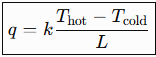

In [34]:
L = 1.0 # m
q_analytical = k_iron_plate * (T_left - T_right) / L
print(f"Analytical |q| = {q_analytical:.6f} W/m²")

Analytical |q| = 6400.000000 W/m²
